In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [2]:
from tensorflow.keras.datasets import fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

In [4]:
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(512, activation="relu"),
    Dense(256, activation="relu"),
    Dense(10, activation="softmax")
])


model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [5]:
history = model.fit(
    x_train,
    y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 23s 25ms/step - accuracy: 0.8263 - loss: 0.4861 - val_accuracy: 0.8648 - val_loss: 0.3745
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.8670 - loss: 0.3629 - val_accuracy: 0.8652 - val_loss: 0.3717
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.8796 - loss: 0.3226 - val_accuracy: 0.8736 - val_loss: 0.3518
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.8883 - loss: 0.2981 - val_accuracy: 0.8746 - val_loss: 0.3577
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.8944 - loss: 0.2841 - val_accuracy: 0.8847 - val_loss: 0.3334
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.8987 - loss: 0.2678 - val_accuracy: 0.8760 - val_loss: 0.3501
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.9039 - loss: 0.2521 - val_accuracy: 0.8842 - val_loss: 0.3293
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 26s 23ms/step - accuracy: 0.9083 - loss: 0.2395 - 

In [6]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8899 - loss: 0.3726
Test Accuracy: 0.8899000287055969


In [7]:
predictions = model.predict(x_test)
predicted_classes = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


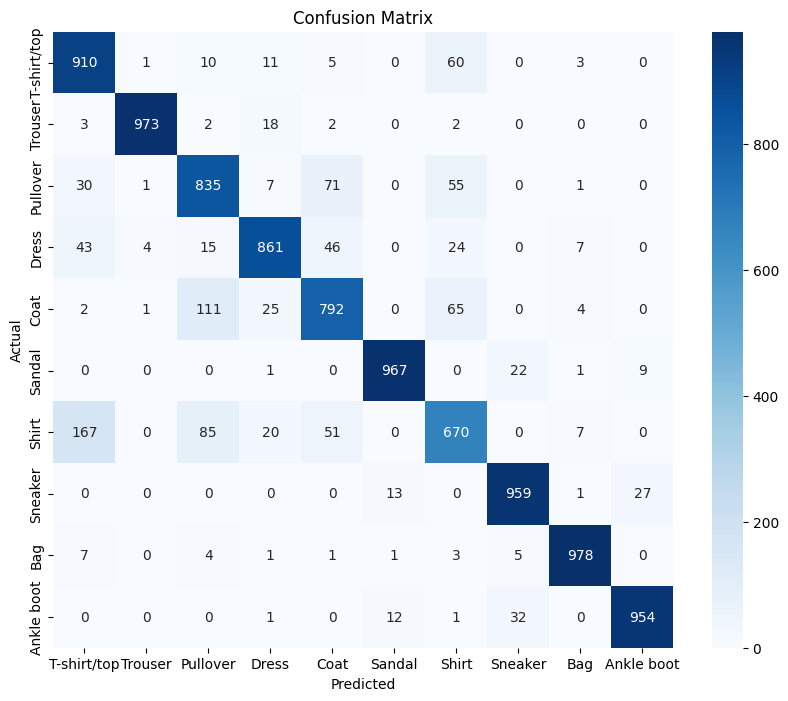

In [8]:
cm = confusion_matrix(y_test, predicted_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [9]:
print(classification_report(
    y_test,
    predicted_classes,
    target_names=class_names
))

              precision    recall  f1-score   support

 T-shirt/top       0.78      0.91      0.84      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.79      0.83      0.81      1000
       Dress       0.91      0.86      0.89      1000
        Coat       0.82      0.79      0.80      1000
      Sandal       0.97      0.97      0.97      1000
       Shirt       0.76      0.67      0.71      1000
     Sneaker       0.94      0.96      0.95      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.96      0.95      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



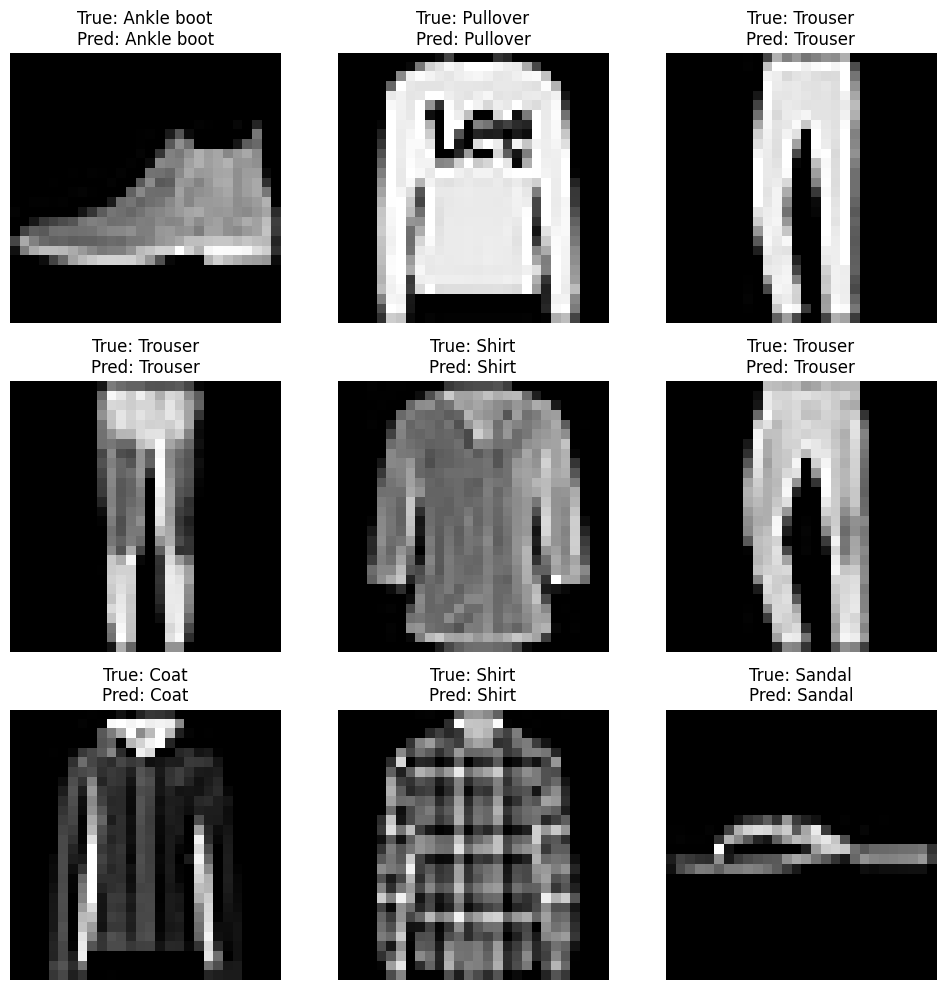

In [10]:
plt.figure(figsize=(10, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_test[i], cmap="gray")
    plt.title(
        f"True: {class_names[y_test[i]]}\nPred: {class_names[predicted_classes[i]]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [12]:
x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_test_cnn = x_test.reshape(-1, 28, 28, 1)

In [13]:
cnn_model = Sequential([

    Conv2D(32, (3,3), activation="relu", input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation="relu"),

    Dense(10, activation="softmax")
])

cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history_cnn = cnn_model.fit(
    x_train_cnn,
    y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 53ms/step - accuracy: 0.8111 - loss: 0.5226 - val_accuracy: 0.8551 - val_loss: 0.4046
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 39s 52ms/step - accuracy: 0.8748 - loss: 0.3469 - val_accuracy: 0.8874 - val_loss: 0.3182
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 42s 53ms/step - accuracy: 0.8936 - loss: 0.2952 - val_accuracy: 0.8927 - val_loss: 0.2959
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - accuracy: 0.9031 - loss: 0.2639 - val_accuracy: 0.8939 - val_loss: 0.2876
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 81s 53ms/step - accuracy: 0.9134 - loss: 0.2381 - val_accuracy: 0.9057 - val_loss: 0.2625
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 39s 52ms/step - accuracy: 0.9204 - loss: 0.2166 - val_accuracy: 0.8967 - val_loss: 0.2851
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 39s 52ms/step - accuracy: 0.9266 - loss: 0.1953 - val_accuracy: 0.9104 - val_loss: 0.2593
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 39s 52ms/step - accuracy: 0.9348 - loss: 0.1779 - 

In [15]:
cnn_loss, cnn_acc = cnn_model.evaluate(x_test_cnn, y_test)

print("CNN Test Accuracy:", cnn_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9079 - loss: 0.3315
CNN Test Accuracy: 0.9078999757766724


In [16]:
cnn_predictions = cnn_model.predict(x_test_cnn)
cnn_predicted_classes = np.argmax(cnn_predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


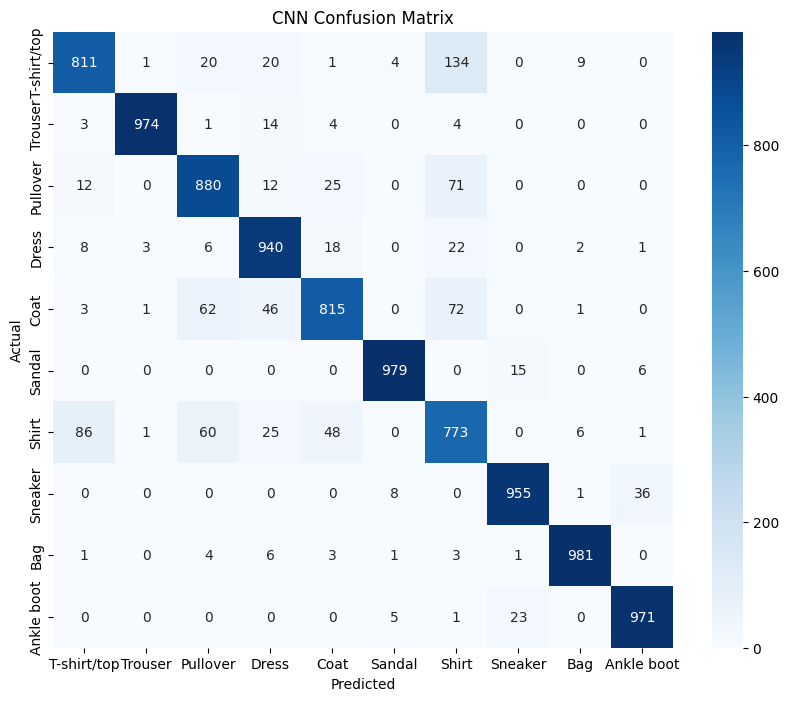

In [17]:
cm = confusion_matrix(y_test, cnn_predicted_classes)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")
plt.show()

In [18]:
print(classification_report(
    y_test,
    cnn_predicted_classes,
    target_names=class_names
))

              precision    recall  f1-score   support

 T-shirt/top       0.88      0.81      0.84      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.85      0.88      0.87      1000
       Dress       0.88      0.94      0.91      1000
        Coat       0.89      0.81      0.85      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.72      0.77      0.74      1000
     Sneaker       0.96      0.95      0.96      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.96      0.97      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



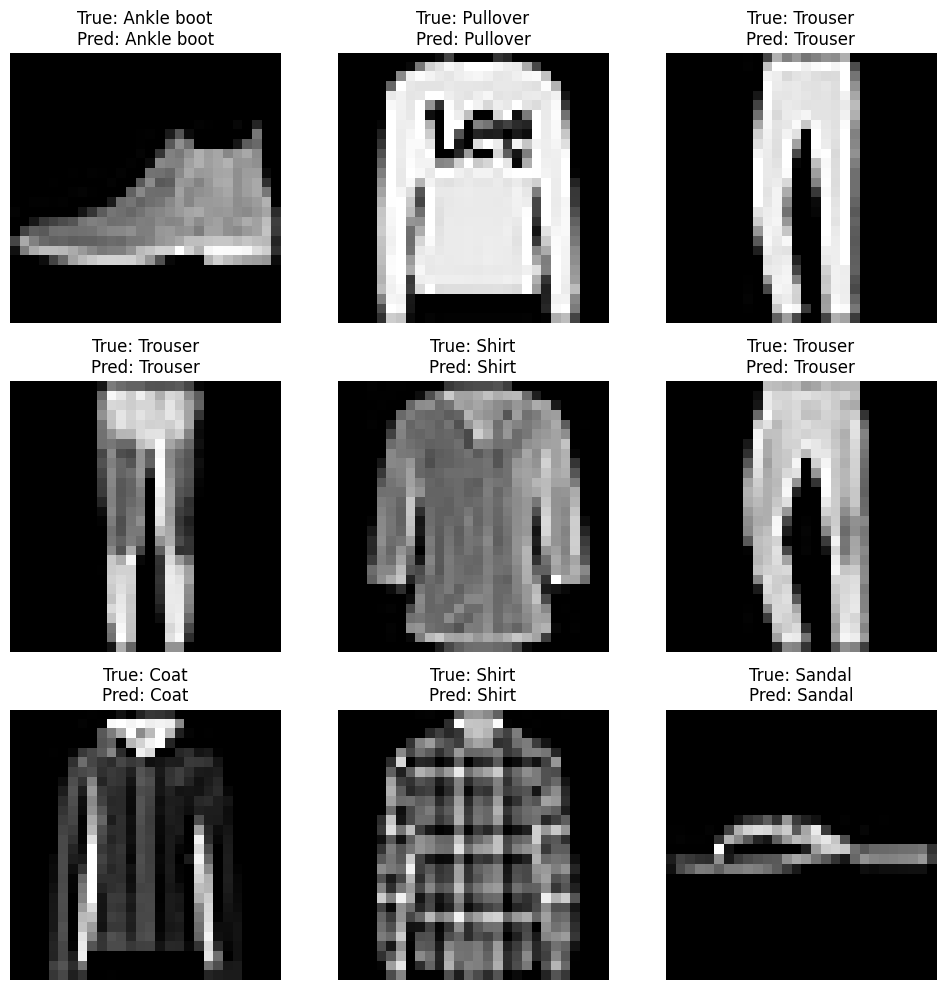

In [19]:
plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_test[i], cmap="gray")
    plt.title(
        f"True: {class_names[y_test[i]]}\nPred: {class_names[cnn_predicted_classes[i]]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [20]:
print(f"ANN Accuracy : {test_accuracy:.4f}")
print(f"CNN Accuracy : {cnn_acc:.4f}")

ANN Accuracy : 0.8899
CNN Accuracy : 0.9079
